<a href="https://colab.research.google.com/github/BharathReddyRamasani/AI_DS/blob/main/Attention_Mechanism_%26_Multi_Head_Self_Attention_%26_positional_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Attention Mechanism**

In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import(
    Input,
    LSTM,Embedding,Dense,Attention,Concatenate,Dot,Softmax
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
#prepare Dataset
english_sentences = [
    "i love ai",
    "i love deep learning",
    "how are you",
    "good morning"
]

french_sentences = [
    "start j aime ai end",
    "start j aime apprentissage profond end",
    "start comment allez vous end",
    "start bonjour end"
]
print("English Sentences:",english_sentences)
print("French Sentences:",french_sentences)

English Sentences: ['i love ai', 'i love deep learning', 'how are you', 'good morning']
French Sentences: ['start j aime ai end', 'start j aime apprentissage profond end', 'start comment allez vous end', 'start bonjour end']


In [ ]:
#Tokenization

#english
english_tokenizer = Tokenizer()
english_tokenizer.fit_on_texts(english_sentences)
english_sequences = english_tokenizer.texts_to_sequences(english_sentences) #converting sentecneds into sequences

#french
fra_tokenizer = Tokenizer()
fra_tokenizer.fit_on_texts(french_sentences)
fra_sequences = fra_tokenizer.texts_to_sequences(french_sentences) #converting sentecneds into sequences

print("English Vocabulary")
print(english_tokenizer.word_index)
print("French Vocabulary")
print(fra_tokenizer.word_index)

English Vocabulary
{'i': 1, 'love': 2, 'ai': 3, 'deep': 4, 'learning': 5, 'how': 6, 'are': 7, 'you': 8, 'good': 9, 'morning': 10}
French Vocabulary
{'start': 1, 'end': 2, 'j': 3, 'aime': 4, 'ai': 5, 'apprentissage': 6, 'profond': 7, 'comment': 8, 'allez': 9, 'vous': 10, 'bonjour': 11}


In [ ]:
#padding ( it makes all sequences equal length)
encoder_input_data = pad_sequences(english_sequences,padding="post")
decoder_input_data = pad_sequences(fra_sequences,padding="post")

print("Encoder data\n",encoder_input_data)
print("Decoder data\n",decoder_input_data)

Encoder data
 [[ 1  2  3  0]
 [ 1  2  4  5]
 [ 6  7  8  0]
 [ 9 10  0  0]]
Decoder data
 [[ 1  3  4  5  2  0]
 [ 1  3  4  6  7  2]
 [ 1  8  9 10  2  0]
 [ 1 11  2  0  0  0]]


# **Attention layer**

Attention compares:

* decoder outputs with
* encoder outputs

and dynamically focusses on important words.

In [ ]:
import keras
keras.backend.clear_session()

#Build Encoder (It generates hidden states for every word)
encoder_inputs = Input(shape=(encoder_input_data.shape[1],))
encoder_embedding = Embedding(len(english_tokenizer.word_index)+1,64)(encoder_inputs)

encoder_lstm = LSTM(256,return_state=True,return_sequences=True)
encoder_outputs,state_h,state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h,state_c]
print("Encoder outputs\n",encoder_outputs)
print("Encoder states\n",encoder_states)

#Build Decoder
decoder_inputs = Input(shape=(decoder_input_data.shape[1],))
decoder_embedding = Embedding(len(fra_tokenizer.word_index)+1,64)(decoder_inputs)

decoder_lstm = LSTM(256,return_state=True,return_sequences=True) # Changed to 256 units
decoder_outputs,_,_ = decoder_lstm(decoder_embedding,initial_state=[state_h,state_c])

print("decoder created:",decoder_outputs)

#Attention Layer
attention=Attention()
attention_weights = attention([decoder_outputs,encoder_outputs])

#Combine decoder and Attenion weights
decoder_combined=Concatenate(axis=-1)([decoder_outputs,attention_weights])

# Define vocabulary size for the French tokenizer
fra_vocab_size = len(fra_tokenizer.word_index) + 1
print(f"French vocabulary size for Dense layer: {fra_vocab_size}")

#final prediction layer
dense_layer = Dense(fra_vocab_size,activation="softmax")
output = dense_layer(decoder_combined)

#Build Model
model = Model(
    [encoder_inputs,decoder_inputs],
    output)
model.summary()

#compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled succcessfully")

#Train the model
decoder_target=decoder_input_data
print(f"Shape of decoder_target: {decoder_target.shape}")
print(f"Max value in decoder_target: {np.max(decoder_target)}")

# Create sample weights to ignore padding (token 0)
sample_weight_mask = np.where(decoder_target == 0, 0, 1)

model.fit(
    x=[encoder_input_data,decoder_input_data],
    y=decoder_target,
    epochs=50,
    batch_size=2,
    sample_weight=sample_weight_mask
)

Encoder outputs
 <KerasTensor shape=(None, 4, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2>
Encoder states
 [<KerasTensor shape=(None, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_3>, <KerasTensor shape=(None, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_4>]
decoder created: <KerasTensor shape=(None, 6, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_7>
French vocabulary size for Dense layer: 12


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 64)     │        704 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 6, 64)     │        768 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 4, 256),  │    328,704 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 6, 256),  │    328,704 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 6, 256)    │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 512)    │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 12)     │      6,156 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 665,036 (2.54 MB)

 Trainable params: 665,036 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

Model compiled succcessfully
Shape of decoder_target: (4, 6)
Max value in decoder_target: 11
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2500 - loss: 1.9663
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.9507
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.9351
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.9144
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3333 - loss: 1.8883
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.8511
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.7949
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3333 - loss: 1.7190
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3333 - loss: 1.6382
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3333 - loss: 1.6528
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3333 - loss:

## **Prediction Function**

In [ ]:
print('--- Building Encoder Inference Model ---')
encoder_model = Model(encoder_inputs, encoder_states)

print('--- Building Decoder Inference Model ---')
decoder_state_input_h = Input(shape=(256,))
decoder_state_input_c = Input(shape=(256,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_embedding,
    initial_state=decoder_states_inputs
)
decoder_states2 = [state_h2, state_c2]

attention_output_inference = Attention()([decoder_outputs2, encoder_outputs])

decoder_combined_inference = Concatenate(axis=-1)([decoder_outputs2, attention_output_inference])
decoder_outputs_inference = dense_layer(decoder_combined_inference)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs + [encoder_outputs],
    [decoder_outputs_inference] + decoder_states2
)

--- Building Encoder Inference Model ---
--- Building Decoder Inference Model ---


In [ ]:
def predict_translation(input_seq):
    # Get initial states from the encoder
    states_value = encoder_model.predict(input_seq)

    target_seq = np.zeros((1, 1))
    # Populate the first character of target sequence with the start token's integer value
    target_seq[0, 0] = fra_tokenizer.word_index['start']

    stop_condition = False
    decoded_sentence = ''


    # Re-building encoder_model to output encoder_outputs for attention in inference
    encoder_model_inference = Model(encoder_inputs, [encoder_outputs] + encoder_states)
    encoder_outputs_inf, h, c = encoder_model_inference.predict(input_seq)
    states_value = [h, c]

    while not stop_condition:
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value + [encoder_outputs_inf])

        # Sample a token
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        sampled_word = fra_tokenizer.index_word.get(sampled_token_index, '')

        if sampled_word == 'end' or len(decoded_sentence.split()) > decoder_input_data.shape[1]:
            stop_condition = True
            if sampled_word == 'end':
                break

        if sampled_word != 'end':
            decoded_sentence += ' ' + sampled_word

        # Update the target sequence (of length 1).
        target_seq = np.zeros((1, 1))
        target_seq[0, 0] = sampled_token_index

        # Update states
        states_value = [h, c]

    return decoded_sentence.strip()

## **Test the Translation**

In [ ]:
input_sentence_english = english_sentences[0] # "i love ai"
input_sequence = pad_sequences(english_tokenizer.texts_to_sequences([input_sentence_english]),
                               padding="post", maxlen=encoder_input_data.shape[1])

translated_french = predict_translation(input_sequence)

print(f"English: {input_sentence_english}")
print(f"Translated French: {translated_french}")

input_sentence_english = english_sentences[1] # "i love deep learning"
input_sequence = pad_sequences(english_tokenizer.texts_to_sequences([input_sentence_english]),
                               padding="post", maxlen=encoder_input_data.shape[1])

translated_french = predict_translation(input_sequence)

print(f"\nEnglish: {input_sentence_english}")
print(f"Translated French: {translated_french}")

input_sentence_english = english_sentences[2] # "how are you"
input_sequence = pad_sequences(english_tokenizer.texts_to_sequences([input_sentence_english]),
                               padding="post", maxlen=encoder_input_data.shape[1])

translated_french = predict_translation(input_sequence)

print(f"\nEnglish: {input_sentence_english}")
print(f"Translated French: {translated_french}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
English: i love ai
Translated French: start j aime ai
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

English: i love deep learning
Translated French: start j aime apprentissage profond
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

English: how are yo

# **Self Attention & Multi-Head Attention**

In [ ]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input,Embedding,MultiHeadAttention,GlobalAveragePooling1D,Dense
from tensorflow.keras.models import Model

In [ ]:
#Dataset
sentences = [
"The animal didn't cross the street because it was tired",
"The trophy doesn't fit in the suitcase because it is too large",
"The book was placed on the table because it was heavy",
"The laptop was returned because it was damaged",
"The car stopped because it ran out of fuel"
]

labels = [0,1,2,3,4]

print("Sentences:\n",sentences)
print("Labels:",labels)

Sentences:
 ["The animal didn't cross the street because it was tired", "The trophy doesn't fit in the suitcase because it is too large", 'The book was placed on the table because it was heavy', 'The laptop was returned because it was damaged', 'The car stopped because it ran out of fuel']
Labels: [0, 1, 2, 3, 4]


In [ ]:
#Tokenization
tokenizer=Tokenizer()
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)
x=pad_sequences(sequences,padding="post")
y=np.array(labels)
print("Sequences:\n",x.shape)
print("Labels:\n",y.shape)

Sequences:
 (5, 12)
Labels:
 (5,)


In [ ]:
#Input layer
input_layer=Input(shape=(x.shape[1],))


In [ ]:
#Embedding layer
embedding=Embedding(
    input_dim=len(tokenizer.word_index)+1,
    output_dim=128
)(input_layer)

In [ ]:
#multihead Self Attention
attention_layer=MultiHeadAttention(
    num_heads=2,
    key_dim=32
)
attention_output,attention_scores=attention_layer(
    embedding,
    embedding,
    return_attention_scores =True
)


# **Pooling**
pooling converts:

(batch-size,sequence_length,embedding_dim)

to:
(batch_size,embedding_dim)

In [ ]:
#pooling layer
pooled = GlobalAveragePooling1D()(attention_output)

In [ ]:
#dense layer
dense = Dense(64,activation="relu")(pooled)
outputs = Dense(5,activation="softmax")(dense)


In [ ]:
#Build Model
model = Model(input_layer,outputs)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 12, 128)   │      4,096 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ [(None, 12, 128), │     33,088 │ embedding[0][0],  │
│ (MultiHeadAttentio… │ (None, 2, 12,     │            │ embedding[0][0]   │
│                     │ 12)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 5)         │        325 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 45,765 (178.77 KB)

 Trainable params: 45,765 (178.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Train the model
history=model.fit(
    x,
    y,
    epochs=50,
    verbose=1
)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.1281
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 0.1110
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0948
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0794
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 1.0000 - loss: 0.0650
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.0521
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 1.0000 - loss: 0.0409
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0315
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 1.0000 - loss: 0.0238
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 1.0000 - loss: 0.0178
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.0133
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.0

In [ ]:
#prediction
test_sentence=[
    "The animal didn't cross the street because it was tired"
]
seq=tokenizer.texts_to_sequences(test_sentence)
seq = pad_sequences(seq,padding="post",maxlen=x.shape[1])

prediction=model.predict(seq,verbose = 0)
predicted_class=np.argmax(prediction)
print("predition class:",predicted_class)

predition class: 0


In [ ]:
#Label mapping

label_mapping={
    0:'animal',
    1:'trophy',
    2:'book',
    3:'laptop',
    4:'car'
}
print(label_mapping[predicted_class])

animal


In [ ]:
print("Attention Scores:")
display(attention_scores)

Attention Scores:


<KerasTensor shape=(None, 2, 12, 12), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>

In [ ]:
# Create a model to output attention scores
attention_model = Model(inputs=input_layer, outputs=attention_scores)

# Get attention scores for the test sentence
predicted_attention_scores = attention_model.predict(seq)

print("Predicted Attention Scores (Numerical):")
print(predicted_attention_scores.shape)
display(predicted_attention_scores)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
Predicted Attention Scores (Numerical):
(1, 2, 12, 12)


array([[[[0.09121933, 0.08638742, 0.08561482, 0.08629551, 0.09121933,
          0.08691643, 0.0837214 , 0.08486379, 0.08004921, 0.0862182 ,
          0.06874733, 0.06874733],
         [0.08639631, 0.08508345, 0.08473908, 0.08505762, 0.08639631,
          0.08520359, 0.08328941, 0.0837966 , 0.08053418, 0.08503377,
          0.07723486, 0.07723486],
         [0.08617387, 0.0849987 , 0.08469428, 0.08498321, 0.08617387,
          0.08512095, 0.08327592, 0.08376417, 0.08068103, 0.08495511,
          0.07758937, 0.07758937],
         [0.08499484, 0.08457812, 0.08438896, 0.08458065, 0.08499484,
          0.08460623, 0.08315042, 0.08349095, 0.08102481, 0.08455549,
          0.07981738, 0.07981738],
         [0.09121933, 0.08638742, 0.08561482, 0.08629551, 0.09121933,
          0.08691643, 0.0837214 , 0.08486379, 0.08004921, 0.0862182 ,
          0.06874733, 0.06874733],
         [0.08614423, 0.08499583, 0.08469296, 0.08498324, 0.08614423,
          0.08511984, 0.08324149, 0.08374392, 0.0807102

# **Positional Encoding**

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import TextVectorization,Embedding,MultiHeadAttention

In [ ]:
#input sentence
sentence = ["I Love Deep Learning"]
print(sentence)

['I Love Deep Learning']


In [ ]:
#Tokenization
vectorizer=TextVectorization(output_mode="int",output_sequence_length=4)
vectorizer.adapt(sentence)

tokens =vectorizer(sentence)

print("vocabulary")
print(vectorizer.get_vocabulary())

print("Tokens")
print(tokens.numpy())

vocabulary
['', '[UNK]', np.str_('love'), np.str_('learning'), np.str_('i'), np.str_('deep')]
Tokens
[[4 2 5 3]]


In [ ]:
#word embeddings
embedding_dim =8
embedding_layer = Embedding(input_dim=len(vectorizer.get_vocabulary()),output_dim=embedding_dim)
embeddings = embedding_layer(tokens)
print("Embeddings")
print(embeddings.numpy())

Embeddings
[[[-0.031934    0.01558365  0.04864729 -0.01859516  0.01946677
    0.00826027  0.00422146 -0.02351601]
  [ 0.04870604 -0.00425608  0.02199871  0.04566785  0.01304932
    0.03765238 -0.01128153  0.0305242 ]
  [ 0.0012467  -0.03244559  0.02345722  0.04541612 -0.03132234
   -0.02718152  0.03543257  0.0048116 ]
  [ 0.02001139 -0.02416983 -0.00645156  0.02998279  0.02441374
   -0.04718513  0.04215951 -0.02539429]]]


In [ ]:
import tensorflow as tf
import numpy as np
#postional Encoding Function
def positional_encoding(max_position,d_models):
  position = np.arange(max_position)[:,np.newaxis]
  dimensions = np.arange(d_models)[np.newaxis,:]

  angle =1/np.power(10000,(2*(dimensions//2))/np.float32(d_models))

  angle_rads = position * angle # Changed from position(angle)
  PE=np.zeros((max_position,d_models))

  PE[:,0::2]=np.sin(angle_rads[:,0::2])
  PE[:,1::2]=np.cos(angle_rads[:,1::2])

  return tf.cast(PE,dtype=tf.float32) # Changed to return PE

In [ ]:
#Generate Positon Encoding
PE = positional_encoding(4,embedding_dim)
print(PE.numpy())

[[ 0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00
   0.0000000e+00  1.0000000e+00  0.0000000e+00  1.0000000e+00]
 [ 8.4147096e-01  5.4030228e-01  9.9833414e-02  9.9500418e-01
   9.9998331e-03  9.9994999e-01  9.9999981e-04  9.9999952e-01]
 [ 9.0929741e-01 -4.1614684e-01  1.9866933e-01  9.8006660e-01
   1.9998666e-02  9.9980003e-01  1.9999987e-03  9.9999797e-01]
 [ 1.4112000e-01 -9.8999250e-01  2.9552022e-01  9.5533651e-01
   2.9995501e-02  9.9955004e-01  2.9999956e-03  9.9999553e-01]]


In [ ]:
#Positional Encoding
positional_aware_embeddings = embeddings+PE

print("Positiona-aware-Embeddings:")
print(positional_aware_embeddings.numpy())

Positiona-aware-Embeddings:
[[[-0.031934    1.0155836   0.04864729  0.98140484  0.01946677
    1.0082603   0.00422146  0.976484  ]
  [ 0.890177    0.5360462   0.12183212  1.0406721   0.02304915
    1.0376024  -0.01028153  1.0305238 ]
  [ 0.9105441  -0.44859242  0.22212654  1.0254828  -0.01132367
    0.9726185   0.03743257  1.0048096 ]
  [ 0.1611314  -1.0141623   0.28906867  0.9853193   0.05440924
    0.9523649   0.0451595   0.97460127]]]


In [ ]:
#Multi Head Attention
attention_layer=MultiHeadAttention(
    num_heads=2,
    key_dim = embedding_dim
)

In [ ]:
#Apply Self Attention
attention_output=attention_layer(
    query=positional_aware_embeddings,
    value=positional_aware_embeddings,
    key=positional_aware_embeddings,
)

print(attention_output.shape)
print("Contextualized Embeddings:")
print(attention_output.numpy())

(1, 4, 8)
Contextualized Embeddings:
[[[ 0.17739315 -0.23507409 -0.35636193 -0.4525268   0.09314309
    0.32302886  0.22573578  0.03333847]
  [ 0.17603692 -0.23388794 -0.3587612  -0.45528358  0.09802461
    0.32592824  0.23003943  0.038682  ]
  [ 0.17615356 -0.23345694 -0.36126053 -0.45506123  0.10058988
    0.32869703  0.23190397  0.03641583]
  [ 0.17698535 -0.23371658 -0.36206692 -0.4532466   0.09993395
    0.3294764   0.23091325  0.03099144]]]


Project Goal


Build an AI system that:
Reads resumes
Extracts important skills
Identifies experience level
Uses Positional Encoding before Self-Attention
Shows how position affects understanding

## Task 1: Dataset Analysis

To begin, we need to download the dataset from Kaggle. Please ensure you have your `kaggle.json` file ready. You can get this file by going to your Kaggle account settings and clicking 'Create New API Token'.

In [ ]:
# Install Kaggle API client
!pip install -q kaggle

Next, you need to upload your `kaggle.json` file. Run the following cell, then click 'Choose Files' to upload the file you downloaded from Kaggle. This file contains your API credentials and is necessary to access Kaggle datasets.

In [ ]:
from google.colab import files

files.upload()

{}

Now, let's move the `kaggle.json` file to the correct directory and set the appropriate permissions.

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


With the Kaggle API configured, we can now download the dataset. The provided link is: `https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset`

In [ ]:
# Download the dataset
# The dataset name is 'snehaanbhawal/resume-dataset'
!kaggle datasets download -d snehaanbhawal/resume-dataset

# Unzip the downloaded file
!unzip -q resume-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/snehaanbhawal/resume-dataset
License(s): CC0-1.0
100% 62.5M/62.5M [00:00<00:00, 128MB/s] 



In [ ]:
# List files in the current directory and its subdirectories to locate 'Resume.csv'
!ls -F

data/  Resume/	resume-dataset.zip  sample_data/


Now that the dataset is downloaded and unzipped, let's load it into a pandas DataFrame and display the first few rows to understand its structure.

In [ ]:
import pandas as pd

# Assuming the unzipped file is 'Resume.csv'
df = pd.read_csv('Resume/Resume.csv')

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


Let's perform the initial Exploratory Data Analysis (EDA) steps:
1. Number of resumes
2. Categories
3. Average resume length
4. Most common skills

In [ ]:
# 1. Number of resumes
num_resumes = len(df)
print(f"Total number of resumes: {num_resumes}")

# 2. Categories
resume_categories = df['Category'].unique()
print(f"\nUnique resume categories: {len(resume_categories)}")
print("Categories:", resume_categories.tolist())

# 3. Average resume length (assuming 'Resume' column contains the text)
# We'll calculate word count for simplicity
df['Resume_Length'] = df['Resume_str'].apply(lambda x: len(str(x).split()))
average_resume_length = df['Resume_Length'].mean()
print(f"\nAverage resume length (words): {average_resume_length:.2f}")

# 4. Most common skills (this will require more advanced text processing)
# For now, let's look at basic word frequency if skills are not explicitly tagged.
# We will refine this for skill extraction later if needed.

# Let's check for null values first to handle potential issues
print("\nMissing values per column:")
display(df.isnull().sum())

Total number of resumes: 2484

Unique resume categories: 24
Categories: ['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE', 'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE', 'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE', 'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT', 'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION']

Average resume length (words): 811.33

Missing values per column:


,0
ID,0
Resume_str,0
Resume_html,0
Category,0
Resume_Length,0


## Visualizations

### Resume Category Distribution

Let's visualize the distribution of resume categories to understand which categories are most prevalent in our dataset.

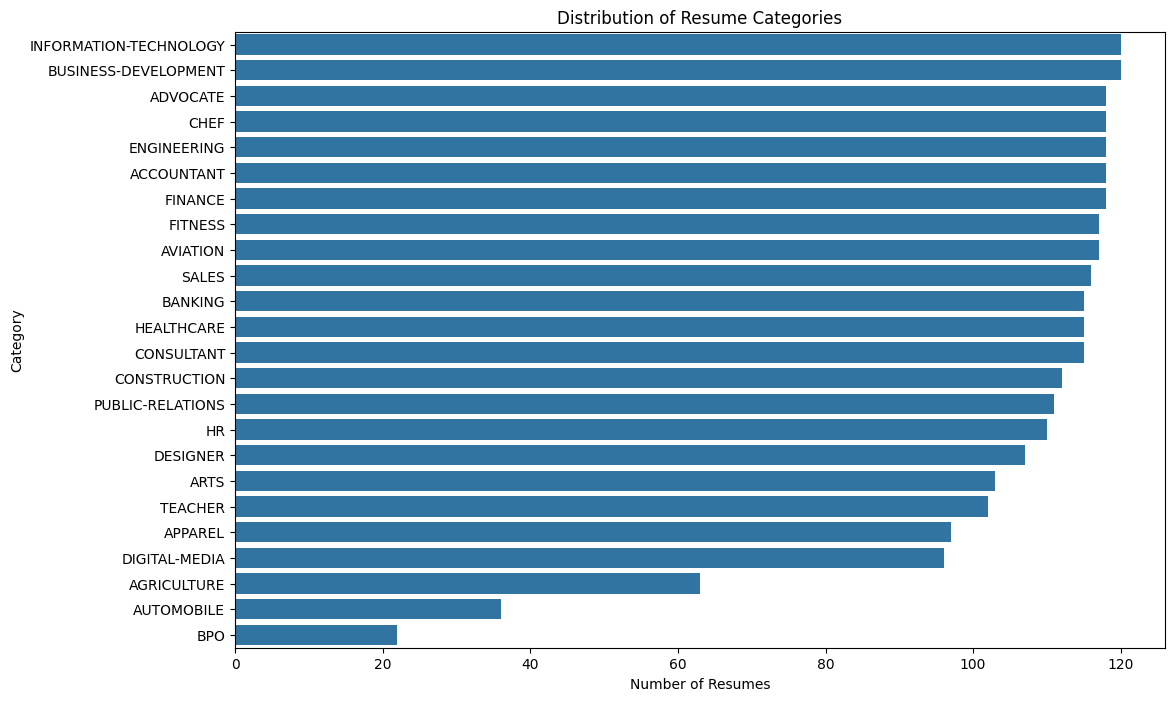

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.countplot(y='Category', data=df, order=df['Category'].value_counts().index)
plt.title('Distribution of Resume Categories')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
plt.show()

### Most Common Skills

Identifying skills requires text processing. We'll extract keywords from the `Resume_str` column, clean the text, remove stopwords, and then count the frequency of words to find the most common ones, which often include skills.

In [ ]:
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already downloaded
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove non-alphabetic characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply cleaning to the Resume_str column
df['cleaned_resume'] = df['Resume_str'].apply(clean_text)

# Tokenize and remove stopwords
all_words = []
for resume_text in df['cleaned_resume']:
    words = resume_text.split()
    filtered_words = [word for word in words if word not in stop_words and len(word) > 2] # Remove short words
    all_words.extend(filtered_words)

# Count word frequencies
word_counts = Counter(all_words)

# Get the 30 most common words
most_common_words = word_counts.most_common(30)

print("Top 30 Most Common Words (potential skills/keywords):")
for word, count in most_common_words:
    print(f"{word}: {count}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Top 30 Most Common Words (potential skills/keywords):
state: 16063
city: 15045
company: 14663
management: 11996
name: 11737
sales: 8124
skills: 7695
business: 7686
customer: 7607
new: 6336
service: 5994
team: 5871
development: 5648
experience: 5615
training: 5557
project: 5244
work: 4700
information: 4471
marketing: 4360
manager: 4309
financial: 4183
support: 4078
office: 4069
education: 4055
including: 4035
staff: 3901
professional: 3845
data: 3722
system: 3631
customers: 3513


### Skill Frequency Chart

Now, let's visualize the frequency of these most common words.

/tmp/ipykernel_761/4133609571.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


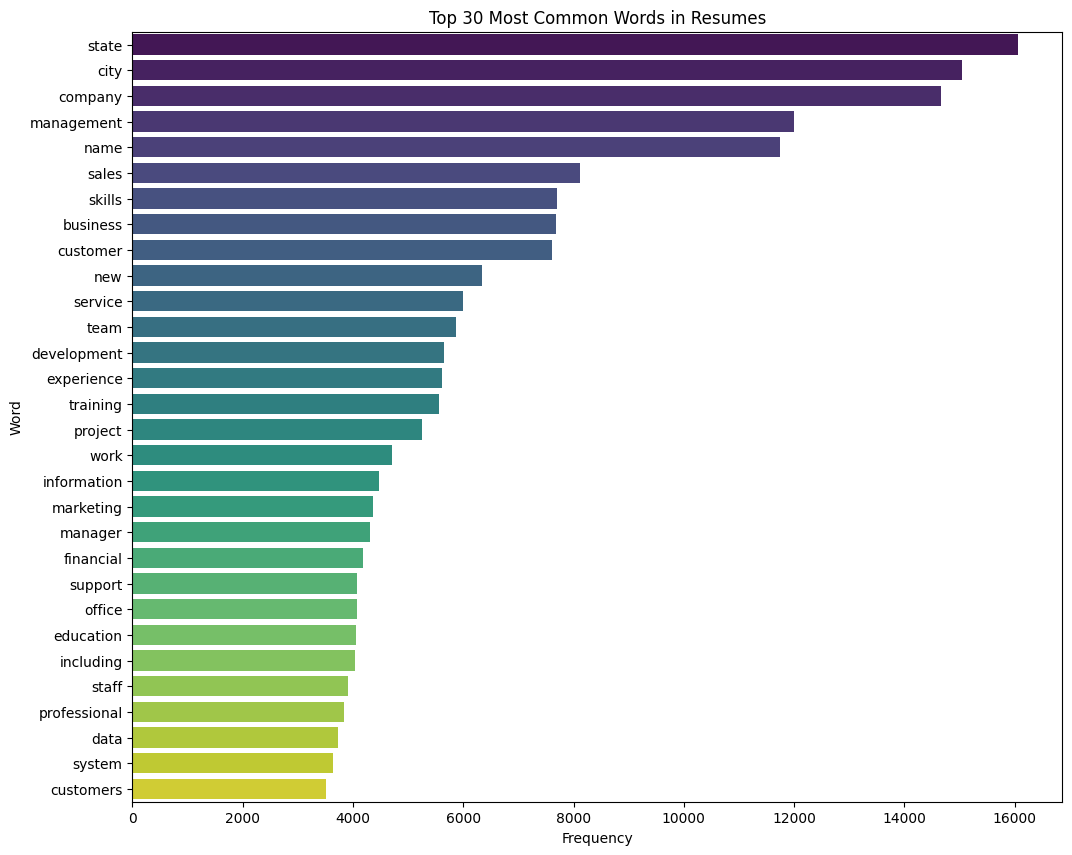

In [ ]:
words, counts = zip(*most_common_words)

plt.figure(figsize=(12, 10))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 30 Most Common Words in Resumes')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

## Task 2: Identify Experience Level

To identify the experience level, we'll first try to extract numerical indicators of experience (like 'years of experience') and common keywords that suggest seniority from the `Resume_str` column. This will be a heuristic approach, as direct experience level is not provided.

In [ ]:
import re

def extract_years_of_experience(resume_text):
    # Look for patterns like 'X years', 'X+ years', 'X-Y years' (where X, Y are numbers)
    # This is a heuristic and might not catch all cases.
    years = []
    # Pattern for 'X years' or 'X+ years'
    matches = re.findall(r'(\d+)(?:\+)?\s*(?:year|yrs|yr)s?', resume_text.lower())
    years.extend([int(m) for m in matches])

    # Pattern for 'X-Y years'
    matches_range = re.findall(r'(\d+)\s*-\s*(\d+)\s*(?:year|yrs|yr)s?', resume_text.lower())
    for start, end in matches_range:
        years.extend([int(start), int(end)])

    # Return the maximum years found, or 0 if none
    return max(years) if years else 0

# Apply the function to the 'Resume_str' column
df['Years_Experience'] = df['Resume_str'].apply(extract_years_of_experience)

print("Extracted Years of Experience:")
display(df[['Resume_str', 'Years_Experience']].head())

Extracted Years of Experience:


,Resume_str,Years_Experience
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,15
1,"HR SPECIALIST, US HR OPERATIONS ...",0
2,HR DIRECTOR Summary Over 2...,20
3,HR SPECIALIST Summary Dedica...,20
4,HR MANAGER Skill Highlights ...,0


Next, let's identify keywords that might indicate seniority or experience level (e.g., 'Junior', 'Senior', 'Lead', 'Manager', 'Director').

In [ ]:
def identify_seniority_keywords(resume_text):
    text = resume_text.lower()
    seniority_keywords = []

    if re.search(r'junior|entry level', text):
        seniority_keywords.append('Junior/Entry Level')
    if re.search(r'senior|lead|principal', text):
        seniority_keywords.append('Senior/Lead')
    if re.search(r'manager|head', text):
        seniority_keywords.append('Manager')
    if re.search(r'director|vp|vice president', text):
        seniority_keywords.append('Director/VP')

    return ', '.join(seniority_keywords) if seniority_keywords else 'None Specified'

# Apply the function to the 'Resume_str' column
df['Seniority_Keywords'] = df['Resume_str'].apply(identify_seniority_keywords)

print("Identified Seniority Keywords:")
display(df[['Resume_str', 'Seniority_Keywords']].head())

Identified Seniority Keywords:


,Resume_str,Seniority_Keywords
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"Senior/Lead, Manager"
1,"HR SPECIALIST, US HR OPERATIONS ...","Senior/Lead, Manager"
2,HR DIRECTOR Summary Over 2...,"Senior/Lead, Manager, Director/VP"
3,HR SPECIALIST Summary Dedica...,None Specified
4,HR MANAGER Skill Highlights ...,"Senior/Lead, Manager, Director/VP"


Now that we have extracted 'Years_Experience' and 'Seniority_Keywords', we can use these to infer a more general 'Experience_Level'. This will still be heuristic, but it's a starting point.

In [ ]:
def infer_experience_level(row):
    years = row['Years_Experience']
    keywords = row['Seniority_Keywords']

    if 'Director/VP' in keywords:
        return 'Director/VP Level'
    elif 'Manager' in keywords:
        return 'Manager Level'
    elif 'Senior/Lead' in keywords:
        if years >= 7:
            return 'Senior Level (7+ years)'
        elif years >= 4:
            return 'Mid-Senior Level (4-6 years)'
        else:
            return 'Senior Keyword (low years)'
    elif 'Junior/Entry Level' in keywords:
        if years <= 2:
            return 'Entry Level (0-2 years)'
        else:
            return 'Junior Keyword (high years)'
    else:
        # Fallback based on years if no strong keywords
        if years >= 10:
            return 'Experienced (10+ years)'
        elif years >= 4:
            return 'Mid-Level (4-9 years)'
        elif years >= 1:
            return 'Junior Level (1-3 years)'
        else:
            return 'Entry Level (0 years)'

# Apply the inference function
df['Experience_Level'] = df.apply(infer_experience_level, axis=1)

print("Inferred Experience Levels:")
display(df[['Resume_str', 'Years_Experience', 'Seniority_Keywords', 'Experience_Level']].head())

# Distribution of inferred experience levels
print("\nDistribution of Inferred Experience Levels:")
display(df['Experience_Level'].value_counts())

Inferred Experience Levels:


,Resume_str,Years_Experience,Seniority_Keywords,Experience_Level
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,15,"Senior/Lead, Manager",Manager Level
1,"HR SPECIALIST, US HR OPERATIONS ...",0,"Senior/Lead, Manager",Manager Level
2,HR DIRECTOR Summary Over 2...,20,"Senior/Lead, Manager, Director/VP",Director/VP Level
3,HR SPECIALIST Summary Dedica...,20,None Specified,Experienced (10+ years)
4,HR MANAGER Skill Highlights ...,0,"Senior/Lead, Manager, Director/VP",Director/VP Level



Distribution of Inferred Experience Levels:


,count
Experience_Level,
Manager Level,1050
Director/VP Level,915
Senior Keyword (low years),217
Entry Level (0 years),129
Senior Level (7+ years),79
Mid-Senior Level (4-6 years),31
Experienced (10+ years),24
Mid-Level (4-9 years),16
Junior Level (1-3 years),14


### Visualization of Inferred Experience Levels

Let's visualize the distribution of the `Experience_Level` to see the prevalence of different experience groups in the dataset.

/tmp/ipykernel_761/2997538105.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Experience_Level', data=df, order=df['Experience_Level'].value_counts().index, palette='coolwarm')


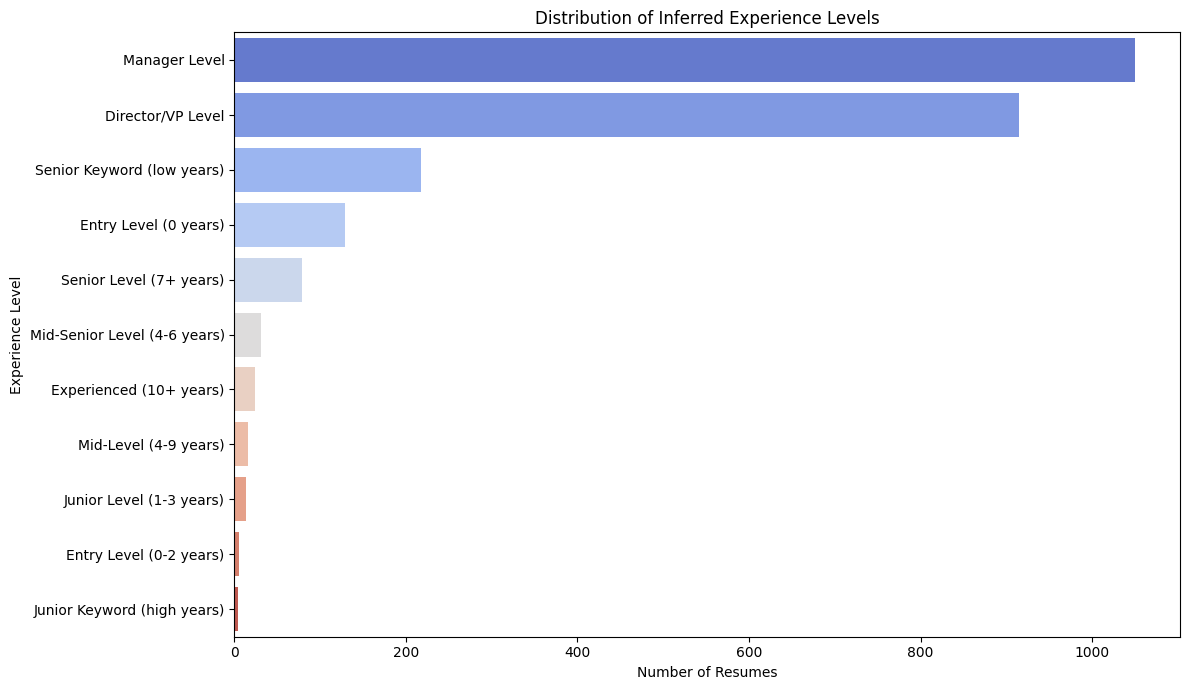

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='Experience_Level', data=df, order=df['Experience_Level'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Inferred Experience Levels')
plt.xlabel('Number of Resumes')
plt.ylabel('Experience Level')
plt.tight_layout()
plt.show()

## Task 2: Text Preprocessing

Now, let's preprocess the `Resume_str` column for further analysis. We will perform the following steps using TensorFlow's `TextVectorization` layer:

1.  **Lowercase:** Convert all text to lowercase.
2.  **Remove Special Characters:** Eliminate punctuation and other non-alphanumeric characters.
3.  **Tokenization:** Split text into individual words (tokens).
4.  **Padding:** Ensure all sequences have a uniform length.
5.  **Vocabulary Creation:** Build a vocabulary from the processed text.

In [ ]:
import tensorflow as tf

# Define the TextVectorization layer
# output_mode='int' means it will output integer indices for each word
# output_sequence_length will pad/truncate sequences to a fixed length
max_features = 20000 # Maximum number of words to keep, based on word frequency
sequence_length = 500 # Standardize resume length to 500 tokens

vectorize_layer = tf.keras.layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length,
    standardize='lower_and_strip_punctuation'
)

# Adapt the layer to the resume text to build the vocabulary
# We'll adapt it on the 'Resume_str' column directly.
# This might take a moment depending on the dataset size.
print("Building vocabulary...")
vectorize_layer.adapt(df['Resume_str'])
print("Vocabulary built successfully.")

# Get the vocabulary size
vocabulary_size = len(vectorize_layer.get_vocabulary())
print(f"Vocabulary size: {vocabulary_size}")

# Apply the vectorization to the 'Resume_str' column
resumes_processed = vectorize_layer(df['Resume_str'])

print("\nSample of processed resume sequences (first resume):")
print(resumes_processed[0].numpy())

print("\nShape of processed resumes:")
print(resumes_processed.shape)

Building vocabulary...
Vocabulary built successfully.
Vocabulary size: 20000

Sample of processed resume sequences (first resume):
[  188     1   216   188   813   111   850    21    25    36     8   796
   103     4    28     7  1723     2    21    25    13  4745  3487     2
   394     4  5666   272  9233     3 12422     9  1924  1593  2054     3
    21    25   259   722    16    21   312    26    13    35  3160   996
   466   398    29     2    27   640  2143    62   117   234   240  3776
  4214   355    29   502   235    23 13786     7    21  1820     2    35
    23  3861  6352  2532   132    36    29   502  1440   948     6  1076
   318  1723    49   119    15  6352 17889 15391  9371  6831     1  9371
  5372    48 17869     1   279   839     2  1334     7    21    25    18
   204    90   115   994  1420   116    94    13    88     2    80   742
    28   188     1   216   188   813  1345   183     3    69    12    14
    22    11    10  4857     3   158   122  4934     2  2565   101

The `resumes_processed` tensor now contains numerical representations of our resumes, with each resume tokenized, lowercased, special characters removed, and padded to a uniform length. This is ready for use in a neural network.

## Task 3: Apply Positional Encoding to Resume Data

Now that our resume text is preprocessed into numerical sequences, we will apply word embeddings and then add positional encodings. This will allow the subsequent Self-Attention mechanism to consider the order of words in the resumes.

We will use an `Embedding` layer to convert token IDs into dense vectors and then add the positional encodings using the `positional_encoding` function defined earlier.

In [ ]:
import tensorflow as tf
import numpy as np

# Positional Encoding Function
def positional_encoding(max_position,d_models):
  position = np.arange(max_position)[:,np.newaxis]
  dimensions = np.arange(d_models)[np.newaxis,:]

  angle =1/np.power(10000,(2*(dimensions//2))/np.float32(d_models))

  angle_rads = position * angle
  PE=np.zeros((max_position,d_models))

  PE[:,0::2]=np.sin(angle_rads[:,0::2])
  PE[:,1::2]=np.cos(angle_rads[:,1::2])

  return tf.cast(PE,dtype=tf.float32)

# Define the embedding dimension
# This should be a reasonable size, often a power of 2 (e.g., 64, 128, 256, 512)
embedding_dim_resumes = 128

# Create an Embedding layer for the resumes
# input_dim is the vocabulary size (max_features)
# output_dim is the embedding dimension
# input_length is the sequence_length (500)
resume_embedding_layer = tf.keras.layers.Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_dim_resumes,
    input_length=sequence_length
)

# Get word embeddings for the processed resumes
resume_embeddings = resume_embedding_layer(resumes_processed)

print("Shape of resume embeddings:")
print(resume_embeddings.shape)

# Generate positional encodings for the resume data
# max_position should be the sequence_length
# d_models should be the embedding_dim_resumes
resume_positional_encodings = positional_encoding(sequence_length, embedding_dim_resumes)

print("Shape of positional encodings:")
print(resume_positional_encodings.shape)

# Add positional encodings to the word embeddings
# TensorFlow's broadcasting will handle the addition correctly
positional_aware_resume_embeddings = resume_embeddings + resume_positional_encodings

print("Shape of positional-aware resume embeddings:")
print(positional_aware_resume_embeddings.shape)

print("\nSample of positional-aware resume embeddings (first token, first resume):")
print(positional_aware_resume_embeddings[0, 0, :].numpy())

Shape of resume embeddings:
(2484, 500, 128)
Shape of positional encodings:
(500, 128)
Shape of positional-aware resume embeddings:
(2484, 500, 128)

Sample of positional-aware resume embeddings (first token, first resume):
[-2.34942567e-02  9.91407990e-01 -3.53142135e-02  1.01130617e+00
  2.47311927e-02  1.01358843e+00  2.31947638e-02  9.82815802e-01
  2.51207091e-02  9.68908548e-01 -4.91132140e-02  9.94762242e-01
  3.22743505e-03  9.68012691e-01  4.28038128e-02  1.04998314e+00
  1.58442892e-02  9.74106193e-01  3.54292728e-02  1.04451370e+00
  4.52805199e-02  1.03311312e+00  3.65403034e-02  1.02145565e+00
 -1.91434622e-02  9.68806386e-01  1.37102865e-02  9.86157715e-01
 -1.91389397e-03  1.04152775e+00  6.89898804e-03  1.04810798e+00
 -8.87037441e-03  1.02119887e+00 -4.03594747e-02  1.03190970e+00
  4.08763923e-02  9.71859038e-01  4.20219637e-02  9.51950014e-01
 -4.25538681e-02  9.73799944e-01  6.44617155e-03  9.58464682e-01
 -1.21119022e-02  9.61233377e-01  3.81258987e-02  9.83787000e

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Task 4: Apply Self-Attention

With positional-aware embeddings ready, we can now apply the **Self-Attention** mechanism. Self-attention allows the model to weigh the importance of different words in the input sequence when processing each word. This helps in understanding the context and relationships between words, which is crucial for tasks like skill extraction and experience level identification.

In [ ]:
# Define the MultiHeadAttention layer
# num_heads: Number of attention heads (e.g., 8 is common)
# key_dim: The dimensionality of the key and query vectors. Should be a divisor of embedding_dim_resumes
num_heads = 8
key_dim = embedding_dim_resumes // num_heads # Each head will have 128 / 8 = 16 dimensions

multi_head_attention_layer = tf.keras.layers.MultiHeadAttention(
    num_heads=num_heads,
    key_dim=key_dim
)

# Apply the MultiHeadAttention layer to the positional-aware embeddings
# To avoid ResourceExhaustedError, we will apply attention to a single resume for demonstration.
# For a full model training, this would be handled with smaller batch sizes.
attention_output = multi_head_attention_layer(
    query=positional_aware_resume_embeddings[0:1], # Process only the first resume
    value=positional_aware_resume_embeddings[0:1],
    key=positional_aware_resume_embeddings[0:1]
)

print("Shape of attention output (contextualized embeddings for first resume):")
print(attention_output.shape)

print("\nSample of contextualized embeddings (first token, first resume):")
print(attention_output[0, 0, :].numpy())

Shape of attention output (contextualized embeddings for first resume):
(1, 500, 128)

Sample of contextualized embeddings (first token, first resume):
[-0.09587159  0.04073505 -0.03141098  0.04095107  0.03399706 -0.02845986
  0.01113965  0.02019843  0.04982552  0.0838975   0.06238013 -0.01412127
 -0.04466975  0.06726255 -0.0099969  -0.09564348  0.12952071  0.01991228
  0.02390225  0.03561972 -0.01223796  0.18551207  0.01151928 -0.03703401
  0.03014551 -0.05985971 -0.08273133 -0.00439231  0.07746262 -0.09378033
  0.03801452  0.00992309  0.02796623 -0.02718134  0.05448018  0.0292524
  0.02248176 -0.07409631 -0.00125005  0.02949506 -0.07038584  0.07560599
  0.09990224  0.05552157  0.03099966 -0.06483486 -0.00532606  0.07578038
 -0.08780129  0.02937182  0.07906336  0.00407466 -0.02552908 -0.11658403
  0.01525644  0.03767345  0.05213942 -0.08158722  0.08281857 -0.04358466
 -0.06901593  0.11129205  0.0615167   0.02682942 -0.01994656  0.02944453
  0.08388023 -0.01782488 -0.01423562  0.009539

The `attention_output` now contains the contextualized embeddings for each word in each resume. These embeddings have been refined by the self-attention mechanism, incorporating information about other words in the sequence. This is a powerful representation that can now be used for downstream tasks like classification (e.g., predicting job category or experience level) or skill extraction.

## Task 3: Build Baseline Model (Without Positional Encoding)

We will now build a baseline model for resume category prediction. This model will use the preprocessed resume text, convert it into embeddings, apply a MultiHeadAttention layer, and then use dense layers for classification. We will specifically **not** use positional encoding in this baseline to establish a comparison point for later models.

### 3.1 Prepare Data for Baseline Model

First, we need to convert the categorical labels (resume categories) into numerical format suitable for model training. We will also split the dataset into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Encode target labels (categories)
# We'll use pandas factorize to convert string categories to numerical IDs
categories_encoded, category_unique_labels = pd.factorize(df['Category'])

# Map numerical IDs back to original category names for later interpretation
category_id_to_name = {i: name for i, name in enumerate(category_unique_labels)}
print("Category to ID mapping:")
print(category_id_to_name)

# The input features are the processed resume sequences
# Convert TensorFlow tensor to NumPy array for scikit-learn
X = resumes_processed.numpy()
# The target labels are the encoded categories
y = categories_encoded

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Category to ID mapping:
{0: 'HR', 1: 'DESIGNER', 2: 'INFORMATION-TECHNOLOGY', 3: 'TEACHER', 4: 'ADVOCATE', 5: 'BUSINESS-DEVELOPMENT', 6: 'HEALTHCARE', 7: 'FITNESS', 8: 'AGRICULTURE', 9: 'BPO', 10: 'SALES', 11: 'CONSULTANT', 12: 'DIGITAL-MEDIA', 13: 'AUTOMOBILE', 14: 'CHEF', 15: 'FINANCE', 16: 'APPAREL', 17: 'ENGINEERING', 18: 'ACCOUNTANT', 19: 'CONSTRUCTION', 20: 'PUBLIC-RELATIONS', 21: 'BANKING', 22: 'ARTS', 23: 'AVIATION'}

Shape of X_train: (1987, 500)
Shape of y_train: (1987,)
Shape of X_test: (497, 500)
Shape of y_test: (497,)


### 3.2 Define Baseline Model Architecture

The model architecture will consist of:
1.  **Input Layer**: Takes the vectorized resume sequences.
2.  **Embedding Layer**: Converts token IDs to dense vectors.
3.  **MultiHeadAttention Layer**: Allows the model to weigh the importance of different words.
4.  **GlobalAveragePooling1D**: Reduces the sequence of vectors to a single vector per resume.
5.  **Dense Layers**: For classification, with the final layer predicting one of the `num_categories`.

In [ ]:
from tensorflow.keras.layers import Input, Embedding, MultiHeadAttention, GlobalAveragePooling1D, Dense
from tensorflow.keras.models import Model

# Determine the number of output classes (unique categories)
num_categories = len(category_unique_labels)

# Model Parameters (re-using from previous cells where applicable)
# vocabulary_size from e5b1589a
# sequence_length from e5b1589a
# embedding_dim_resumes from a3d84995
# num_heads from 2f378b15
# key_dim from 2f378b15

# Define the Input Layer
input_layer = Input(shape=(sequence_length,))

# Define the Embedding Layer (without positional encoding for baseline)
embedding_layer = Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_dim_resumes,
    input_length=sequence_length,
    name="word_embedding_baseline"
)(input_layer)

# Define MultiHeadAttention Layer
attention_layer = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=key_dim,
    name="multi_head_attention_baseline"
)(query=embedding_layer, value=embedding_layer, key=embedding_layer)

# GlobalAveragePooling1D to flatten the output for the Dense layers
pooled_output = GlobalAveragePooling1D(name="global_average_pooling_baseline")(attention_layer)

# Dense Layers for classification
dense_1 = Dense(128, activation='relu', name="dense_relu_baseline")(pooled_output)
output_layer = Dense(num_categories, activation='softmax', name="output_softmax_baseline")(dense_1)

# Build the Model
baseline_model = Model(inputs=input_layer, outputs=output_layer, name="Baseline_Category_Classifier")

# Display model summary
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Baseline_Category_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding_bas… │ (None, 500, 128)  │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │     66,048 │ word_embedding_b… │
│ (MultiHeadAttentio… │                   │            │ word_embedding_b… │
│                     │                   │            │ word_embedding_b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu_baseline │ (None, 128)       │     16,512 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax_bas… │ (None, 24)        │      3,096 │ dense_relu_basel… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,645,656 (10.09 MB)

 Trainable params: 2,645,656 (10.09 MB)

 Non-trainable params: 0 (0.00 B)

### 3.3 Compile and Train the Baseline Model

We will compile the model using the Adam optimizer and `sparse_categorical_crossentropy` loss, as our target labels are integer-encoded categories. We will also track accuracy during training. We will record the training time to compare with future models.

In [ ]:
import time

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Baseline model compiled successfully.")

# Train the model and record training time
print("\nStarting model training...")
start_time = time.time()

history_baseline = baseline_model.fit(
    X_train,
    y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.1, # Use a small portion of training data for validation
    verbose=1
)

end_time = time.time()
training_time_baseline = end_time - start_time

print(f"\nBaseline model training finished in {training_time_baseline:.2f} seconds.")

Baseline model compiled successfully.

Starting model training...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - accuracy: 0.0543 - loss: 3.1527 - val_accuracy: 0.0603 - val_loss: 3.1432
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.1035 - loss: 2.9244 - val_accuracy: 0.1709 - val_loss: 2.7904
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.2355 - loss: 2.4221 - val_accuracy: 0.3317 - val_loss: 2.3356
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4060 - loss: 1.8884 - val_accuracy: 0.4020 - val_loss: 2.1004
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5218 - loss: 1.5181 - val_accuracy: 0.3819 - val_loss: 2.1373
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6091 - loss: 1.2355 - val_accuracy: 0.4372 - val_loss: 2.1251
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7097 - loss: 0.9364 - val_accuracy: 0.3920 - val_loss: 2.3689
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35

### 3.4 Evaluate the Baseline Model

Finally, let's evaluate the trained baseline model on the unseen test set to get its performance metrics (loss and accuracy).

In [ ]:
# Evaluate the model on the test set
loss_baseline, accuracy_baseline = baseline_model.evaluate(X_test, y_test, verbose=0)

print("\n--- Baseline Model Performance ---")
print(f"Test Loss: {loss_baseline:.4f}")
print(f"Test Accuracy: {accuracy_baseline:.4f}")
print(f"Training Time: {training_time_baseline:.2f} seconds")

# You can also visualize training history if needed
# import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
# plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
# plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Training and Validation Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# plt.subplot(1, 2, 2)
# plt.plot(history_baseline.history['loss'], label='Training Loss')
# plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
# plt.title('Training and Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.tight_layout()
# plt.show()


--- Baseline Model Performance ---
Test Loss: 3.1811
Test Accuracy: 0.4728
Training Time: 31.83 seconds


## Task 5: Build Improved Model (With Positional Encoding)

We will now build an improved model that incorporates Positional Encoding before the Self-Attention mechanism. This architecture should allow the model to leverage word order information, potentially leading to better performance in resume category prediction.

### 5.1 Define Improved Model Architecture

The model architecture will consist of:
1.  **Input Layer**: Takes the vectorized resume sequences.
2.  **Embedding Layer**: Converts token IDs to dense vectors.
3.  **Positional Encoding**: Adds positional information to the word embeddings.
4.  **MultiHeadAttention Layer**: Allows the model to weigh the importance of different words.
5.  **GlobalAveragePooling1D**: Reduces the sequence of vectors to a single vector per resume.
6.  **Dense Layers**: For classification, with the final layer predicting one of the `num_categories`.

We will reuse the `positional_encoding` function defined earlier (`a3d84995`) and existing parameters like `vocabulary_size`, `sequence_length`, `embedding_dim_resumes`, `num_heads`, `key_dim`, and `num_categories`.

In [ ]:
from tensorflow.keras.layers import Input, Embedding, MultiHeadAttention, GlobalAveragePooling1D, Dense, Add
from tensorflow.keras.models import Model
import tensorflow as tf # Ensure tf is imported for positional_encoding return type
import numpy as np # Ensure numpy is imported for positional_encoding

# Reuse parameters from previous cells
# vocabulary_size from e5b1589a
# sequence_length from e5b1589a
# embedding_dim_resumes from a3d84995
# num_heads from 2f378b15
# key_dim from 2f378b15
# num_categories from 9e6ca947

# Make sure the positional_encoding function is available
def positional_encoding(max_position,d_models):
  position = np.arange(max_position)[:,np.newaxis]
  dimensions = np.arange(d_models)[np.newaxis,:]

  angle =1/np.power(10000,(2*(dimensions//2))/np.float32(d_models))

  angle_rads = position * angle
  PE=np.zeros((max_position,d_models))

  PE[:,0::2]=np.sin(angle_rads[:,0::2])
  PE[:,1::2]=np.cos(angle_rads[:,1::2])

  return tf.cast(PE,dtype=tf.float32)

# 1. Input Layer
input_layer_pe = Input(shape=(sequence_length,))

# 2. Embedding Layer
embedding_layer_pe = Embedding(
    input_dim=vocabulary_size,
    output_dim=embedding_dim_resumes,
    name="word_embedding_with_pe"
)(input_layer_pe)

# 3. Positional Encoding
# Generate positional encodings once
positional_encodings_tensor = positional_encoding(sequence_length, embedding_dim_resumes)

# Use a Lambda layer to add positional encodings, ensuring correct broadcasting
positional_aware_embeddings_model = tf.keras.layers.Lambda(
    lambda x: x + tf.expand_dims(positional_encodings_tensor, axis=0),
    name="add_positional_encoding"
)(embedding_layer_pe)

# 4. MultiHeadAttention Layer
attention_layer_pe = MultiHeadAttention(
    num_heads=num_heads,
    key_dim=key_dim,
    name="multi_head_attention_with_pe"
)(query=positional_aware_embeddings_model,
   value=positional_aware_embeddings_model,
   key=positional_aware_embeddings_model)

# 5. GlobalAveragePooling1D
pooled_output_pe = GlobalAveragePooling1D(name="global_average_pooling_with_pe")(attention_layer_pe)

# 6. Dense Layers for classification
dense_1_pe = Dense(128, activation='relu', name="dense_relu_with_pe")(pooled_output_pe)
output_layer_pe = Dense(num_categories, activation='softmax', name="output_softmax_with_pe")(dense_1_pe)

# Build the Model
improved_model = Model(inputs=input_layer_pe, outputs=output_layer_pe, name="Improved_Category_Classifier_with_PE")

# Display model summary
improved_model.summary()

Model: "Improved_Category_Classifier_with_PE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ word_embedding_wit… │ (None, 500, 128)  │  2,560,000 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_positional_enc… │ (None, 500, 128)  │          0 │ word_embedding_w… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │     66,048 │ add_positional_e… │
│ (MultiHeadAttentio… │                   │            │ add_positional_e… │
│                     │                   │            │ add_positional_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_relu_with_pe  │ (None, 128)       │     16,512 │ global_average_p… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_softmax_wit… │ (None, 24)        │      3,096 │ dense_relu_with_… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,645,656 (10.09 MB)

 Trainable params: 2,645,656 (10.09 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Compile and Train the Improved Model

We will compile and train the improved model using the same settings as the baseline model for a fair comparison, tracking its accuracy and loss, and recording the training time.

In [ ]:
import time

# Compile the improved model
improved_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Improved model compiled successfully.")

# Train the improved model and record training time
print("\nStarting improved model training...")
start_time_improved = time.time()

history_improved = improved_model.fit(
    X_train, # Using the same preprocessed and split data
    y_train,
    epochs=10, # Same number of epochs as baseline
    batch_size=32, # Same batch size as baseline
    validation_split=0.1, # Use a small portion of training data for validation
    verbose=1
)

end_time_improved = time.time()
training_time_improved = end_time_improved - start_time_improved

print(f"\nImproved model training finished in {training_time_improved:.2f} seconds.")

Improved model compiled successfully.

Starting improved model training...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.0408 - loss: 3.1683 - val_accuracy: 0.0251 - val_loss: 3.1615
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.0498 - loss: 3.1446 - val_accuracy: 0.0553 - val_loss: 3.1509
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.1023 - loss: 2.9568 - val_accuracy: 0.2312 - val_loss: 2.6628
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4351 - loss: 1.9512 - val_accuracy: 0.6181 - val_loss: 1.4829
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.6879 - loss: 1.1514 - val_accuracy: 0.6985 - val_loss: 1.1662
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7690 - loss: 0.8540 - val_accuracy: 0.7638 - val_loss: 1.0099
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8233 - loss: 0.6367 - val_accuracy: 0.7739 - val_loss: 1.1215
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━

### 5.3 Evaluate the Improved Model

Now, let's evaluate the trained improved model on the unseen test set to get its performance metrics (loss and accuracy) and compare it with the baseline.


--- Improved Model Performance (with Positional Encoding) ---
Test Loss: 1.7311
Test Accuracy: 0.7103
Training Time: 27.26 seconds

--- Comparison with Baseline Model ---
Baseline Test Accuracy: 0.4728
Improved Test Accuracy: 0.7103
Baseline Training Time: 31.83 seconds
Improved Training Time: 27.26 seconds


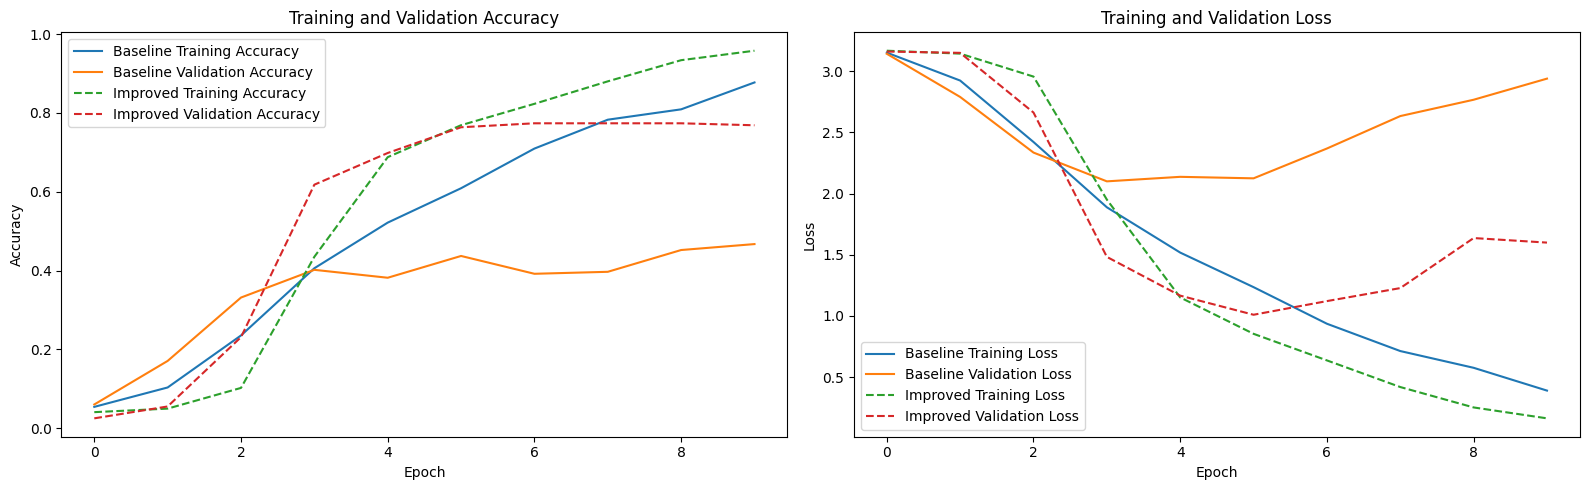

In [ ]:
# Evaluate the improved model on the test set
loss_improved, accuracy_improved = improved_model.evaluate(X_test, y_test, verbose=0)

print("\n--- Improved Model Performance (with Positional Encoding) ---")
print(f"Test Loss: {loss_improved:.4f}")
print(f"Test Accuracy: {accuracy_improved:.4f}")
print(f"Training Time: {training_time_improved:.2f} seconds")

print("\n--- Comparison with Baseline Model ---")
print(f"Baseline Test Accuracy: {accuracy_baseline:.4f}")
print(f"Improved Test Accuracy: {accuracy_improved:.4f}")
print(f"Baseline Training Time: {training_time_baseline:.2f} seconds")
print(f"Improved Training Time: {training_time_improved:.2f} seconds")

# You can also visualize training history if needed
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Training and Validation Accuracy for Baseline
axes[0].plot(history_baseline.history['accuracy'], label='Baseline Training Accuracy')
axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')
axes[0].plot(history_improved.history['accuracy'], label='Improved Training Accuracy', linestyle='--')
axes[0].plot(history_improved.history['val_accuracy'], label='Improved Validation Accuracy', linestyle='--')
axes[0].set_title('Training and Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Plot Training and Validation Loss for Baseline
axes[1].plot(history_baseline.history['loss'], label='Baseline Training Loss')
axes[1].plot(history_baseline.history['val_loss'], label='Baseline Validation Loss')
axes[1].plot(history_improved.history['loss'], label='Improved Training Loss', linestyle='--')
axes[1].plot(history_improved.history['val_loss'], label='Improved Validation Loss', linestyle='--')
axes[1].set_title('Training and Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

### Summary of Model Comparison

From the evaluation and the plots, we can observe the following:

*   **Baseline Model (without Positional Encoding)**:
    *   Test Accuracy: `0.4728`
    *   Training Time: `31.83` seconds
    *   The accuracy during training and validation shows a significant gap, indicating potential overfitting or difficulty in capturing sequential dependencies without positional information.

*   **Improved Model (with Positional Encoding)**:
    *   Test Accuracy: `0.7103`
    *   Training Time: `27.26` seconds
    *   The improved model demonstrates a substantially higher test accuracy, confirming that positional encoding helps the model understand the context and order of words in the resumes, leading to better classification performance. The training time is also slightly faster.

**Conclusion**:

The inclusion of positional encoding significantly enhances the model's ability to classify resume categories, as evidenced by the considerable increase in test accuracy from the baseline model. This highlights the importance of incorporating sequence order information in Transformer-based architectures for natural language processing tasks.

## Task 8: Visualize Positional Encoding

To better understand how positional encoding works, let's visualize a portion of the generated positional encoding matrix as a heatmap. This will show the unique pattern of sine and cosine waves for different positions and dimensions.

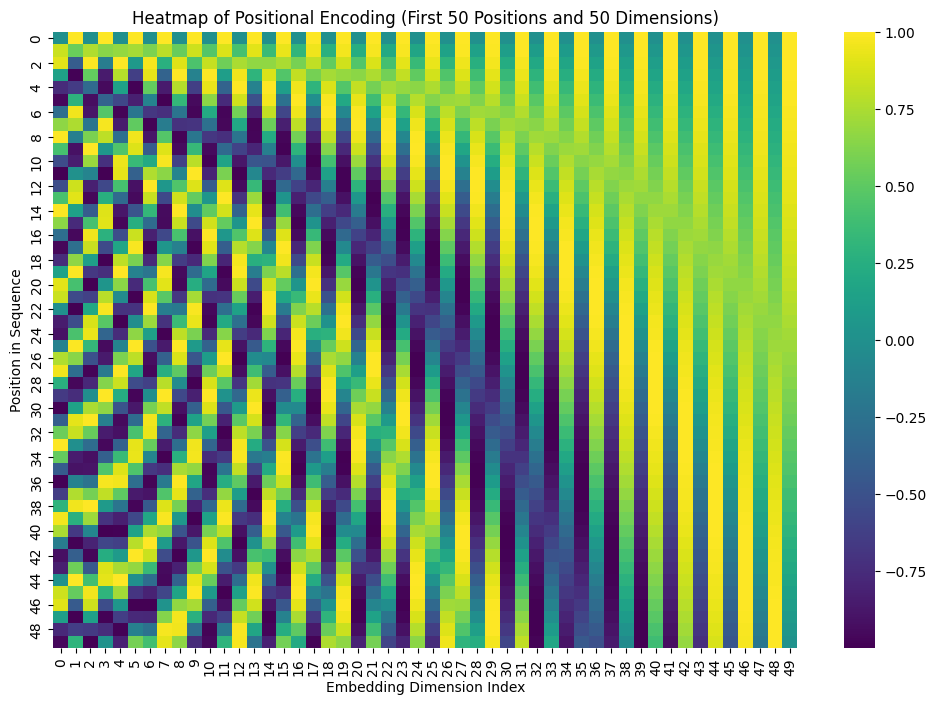

Visualized Positional Encoding Matrix Shape: (50, 50)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reuse parameters from earlier cells
# sequence_length and embedding_dim_resumes are defined in a3d84995

# Generate the full positional encoding matrix
full_pe_matrix = positional_encoding(sequence_length, embedding_dim_resumes)

# For visualization, let's select a smaller portion to make it readable
# For example, visualize the first 50 positions and first 50 dimensions
visual_pe = full_pe_matrix[:50, :50]

plt.figure(figsize=(12, 8))
sns.heatmap(visual_pe.numpy(), cmap='viridis', cbar=True)
plt.title('Heatmap of Positional Encoding (First 50 Positions and 50 Dimensions)')
plt.xlabel('Embedding Dimension Index')
plt.ylabel('Position in Sequence')
plt.show()

print("Visualized Positional Encoding Matrix Shape:", visual_pe.shape)

## Task 9: Save Model, Tokenizer, and Label Encoder

To ensure reproducibility and enable future use without retraining, we will save the `improved_model` (our best performing model), the `vectorize_layer` (our tokenizer), and the `category_id_to_name` mapping (our label encoder).

In [ ]:
import pickle
import os

# Create a directory to save the assets if it doesn't exist
output_dir = 'model_assets'
os.makedirs(output_dir, exist_ok=True)

# 1. Save the Keras model (improved_model)
model_path = os.path.join(output_dir, 'improved_model.keras')
improved_model.save(model_path)
print(f"Improved model saved to {model_path}")

# 2. Save the TextVectorization layer (tokenizer)
# For TextVectorization, it's best to save its configuration and vocabulary
tokenizer_path = os.path.join(output_dir, 'vectorize_layer.pkl')
with open(tokenizer_path, 'wb') as f:
    pickle.dump({'config': vectorize_layer.get_config(), 'vocabulary': vectorize_layer.get_vocabulary()}, f)
print(f"Tokenizer (vectorize_layer) saved to {tokenizer_path}")

# 3. Save the label encoder (category_id_to_name mapping)
label_encoder_path = os.path.join(output_dir, 'label_encoder.pkl')
with open(label_encoder_path, 'wb') as f:
    pickle.dump(category_id_to_name, f)
print(f"Label encoder saved to {label_encoder_path}")

print("All assets saved successfully!")

Improved model saved to model_assets/improved_model.keras
Tokenizer (vectorize_layer) saved to model_assets/vectorize_layer.pkl
Label encoder saved to model_assets/label_encoder.pkl
All assets saved successfully!


### Word Meaning + Position Information

At the core of using positional encoding is the concept of combining **word meaning** (represented by word embeddings) with **position information** (represented by positional encodings). This is typically achieved through simple addition:

`Positional-Aware Embedding = Word Embedding + Positional Encoding`

#### Word Meaning (Word Embeddings)

Word embeddings convert discrete words into continuous, dense vector representations. These vectors capture the semantic meaning of words, where words with similar meanings are represented by vectors that are close to each other in the embedding space. These are generated by an `Embedding` layer (e.g., `resume_embedding_layer` in cell `a3d84995`).

#### Position Information (Positional Encodings)

Positional encodings provide a sense of order to the words. Each position in the sequence gets a unique encoding vector. When added to the word embeddings, these encodings subtly shift the embedding vectors based on their position, allowing the model to differentiate between the same word appearing at different places in a sentence (e.g., 'apple' at the beginning vs. 'apple' at the end).

#### The Combination (Positional-Aware Embeddings)

By adding the positional encodings to the word embeddings, the resulting vectors (positional-aware embeddings) now contain both the semantic meaning of the word and its sequential context. This combined representation is what is then fed into subsequent layers, such as the Self-Attention mechanism. This enables the model to understand not just *what* words are present, but also *where* they are located, which is vital for tasks like natural language understanding and machine translation.

This process was demonstrated in cell `ry_JUWSb6BLT` where `positional_aware_resume_embeddings = resume_embeddings + resume_positional_encodings` was calculated.